# 🤖 Modelado Supervisado H2O + GPU + Paralelo - Precios Inmobiliarios Dinamarca

**Objetivo**: Construir modelos distribuidos H2O, clásicos sklearn y de árbol con optimizaciones GPU y paralelización, evaluarlos con métricas sólidas considerando rendimiento y velocidad.

1. División de Datos (Temporal)

    1.1 Split temporal (80% train, 20% test)

    1.2 Validación de distribución en train/test

    1.3 Visualización de drift o cambios en el tiempo (si aplica)

2. Modelos Estadísticos

    2.1 Regresión Lineal, Ridge, Lasso, ElasticNet

    2.2 Ajuste con mínimos cuadrados o likelihood

    2.3 Comparación de modelos con AIC/BIC (sin CV)

    2.4 Diagnóstico de residuos y detección de outliers

3. Modelos de Árboles

    3.1 LightGBM y Random Forest (hiperparámetros por defecto o mínimos)

    3.2 Comparación con modelos estadísticos

    3.3 Feature importance y explicabilidad inicial

6. Evaluación General

    6.1 Métricas: RMSE, MAE, MAPE, R²

    6.2 Visualización de errores (residuos, pred vs real)

    6.3 Análisis por segmentos (tipo de casa, región)

    6.4 Tabla resumen de modelos y conclusiones

## Requistos previos

```
feature_engineered_complete.parquet, modeling_dataset.parquet, train_data.parquet, test_data.parquet

scalers.pkl, selected_features.txt
```

Obtener los datos de `04_feature_engineering.ipynb` 

In [31]:
from setup import set_project_root
set_project_root()

from src.config import *
from src.descriptive_analysis import (
    load_and_validate_data,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings




Current working directory: c:\Users\rosar\RufoEsEterno\DataMining\Denmark-HousePrices-Analysis


## 1. División de Datos (Temporal)

### 1.1 Split temporal (80% train, 20% test)

Se cargan los datos generados en la extracción de características.

In [32]:
import h2o 
from h2o.estimators import H2OXGBoostEstimator
from joblib import load
import pandas as pd


In [33]:
# 🚀 Iniciar H2O
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,2 hours 0 mins
H2O_cluster_timezone:,America/Lima
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,9 days
H2O_cluster_name:,H2O_from_python_rosar_q3obu6
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.026 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


In [34]:

# 📦 Cargar datos en pandas y escalar
train = pd.read_parquet(TRAIN_DATA_FILE)
test = pd.read_parquet(TEST_DATA_FILE)

features = open(SELECTED_FEATURES_FILE).read().splitlines()
scalers = load(SCALERS_FILE)


In [35]:
train.describe()


,month_sin,month_cos,quarter_sin,quarter_cos,price_deviation_from_median,log_price,price_per_sqm,price_per_sqm_x_region,is_premium,time_trend,...,property_age,sqm,region_target_encoded,age_x_villa,region_frequency,region_count,sqm_x_region,rooms_sqm_ratio,no_rooms,purchase_price
count,893112.000000,893112.000000,893112.000000,893112.000000,8.931120e+05,893112.000000,893112.000000,893112.000000,893112.000000,893112.000000,...,893112.000000,893112.000000,893112.000000,893112.000000,893112.000000,893112.000000,893112.000000,893112.000000,893112.000000,8.931120e+05
mean,0.484769,0.479721,0.509757,0.483613,1.289758e+05,13.974267,0.084428,0.149188,0.060528,0.450166,...,0.260460,0.125885,-0.023174,0.115536,-0.801215,628516.523630,-0.067321,0.106726,0.050920,1.573563e+06
std,0.355010,0.351177,0.358712,0.347796,1.466773e+06,0.746640,0.798566,0.796118,0.238462,0.221997,...,0.927277,0.813850,0.993301,0.653684,1.184820,187311.727007,0.801108,0.943875,1.012637,1.489907e+06
min,0.000000,0.000000,0.000000,0.000000,-1.593968e+06,12.429260,-0.805018,-8.047822,0.000000,0.000000,...,-1.204082,-1.366197,-1.870324,-1.204082,-4.676298,15893.000000,-22.601943,-3.193390,-2.042926,2.500100e+05
25%,0.066987,0.066987,0.500000,0.000000,-6.900000e+05,13.434252,-0.436405,-0.207323,0.000000,0.281250,...,-0.265306,-0.450704,-0.777622,-0.061224,-1.000000,597090.000000,-0.525716,-0.472207,-0.831176,6.830000e+05
50%,0.500000,0.500000,0.500000,0.500000,-2.486208e+05,13.953097,-0.167453,0.190533,0.000000,0.468750,...,0.020408,0.042254,-0.777622,0.000000,0.000000,755183.000000,-0.065715,0.000000,-0.225302,1.147500e+06
75%,0.750000,0.750000,1.000000,0.500000,5.000000e+05,14.483340,0.313116,0.425091,0.000000,0.656250,...,0.755102,0.549296,1.226500,0.081633,0.000000,755183.000000,0.383335,0.532020,0.380573,1.950000e+06
max,1.000000,1.000000,1.000000,1.000000,4.475500e+07,17.644152,4.323574,5.302862,1.000000,0.781250,...,19.693878,12.309859,1.226500,19.693878,0.000000,755183.000000,15.098038,32.389163,6.439319,4.600000e+07


In [36]:
test.describe()

,month_sin,month_cos,quarter_sin,quarter_cos,price_deviation_from_median,log_price,price_per_sqm,price_per_sqm_x_region,is_premium,time_trend,...,property_age,sqm,region_target_encoded,age_x_villa,region_frequency,region_count,sqm_x_region,rooms_sqm_ratio,no_rooms,purchase_price
count,613479.000000,613479.000000,613479.000000,613479.000000,6.134790e+05,613479.000000,613479.000000,613479.000000,613479.000000,613479.000000,...,613479.000000,613479.000000,613479.000000,613479.000000,613479.000000,613479.000000,613479.000000,613479.000000,613479.000000,6.134790e+05
mean,0.514067,0.470988,0.532498,0.503455,9.499608e+05,14.419053,0.608882,0.392892,0.155524,0.901957,...,0.124803,0.033467,0.033736,0.055963,-0.808282,627399.226723,-0.103849,0.131425,-0.074130,2.412784e+06
std,0.354532,0.351095,0.353020,0.352575,1.943399e+06,0.755822,1.027324,1.262376,0.362404,0.057924,...,0.941828,0.790330,1.008723,0.633803,1.158623,183170.229358,0.782793,0.966108,0.976578,2.001308e+06
min,0.000000,0.000000,0.000000,0.000000,-1.593922e+06,12.429540,-0.795691,-8.086483,0.000000,0.812500,...,-1.204082,-1.366197,-1.870324,-1.204082,-4.676298,15893.000000,-11.801481,-3.211410,-2.042926,2.500800e+05
25%,0.250000,0.066987,0.500000,0.500000,-2.870000e+05,13.910822,-0.152395,-0.270564,0.000000,0.843750,...,-0.408163,-0.535211,-0.777622,-0.040816,-1.000000,597090.000000,-0.586878,-0.467980,-0.831176,1.100000e+06
50%,0.500000,0.500000,0.500000,0.500000,4.559975e+05,14.444120,0.320265,0.146759,0.000000,0.906250,...,-0.061224,-0.056338,-0.777622,0.000000,-1.000000,597090.000000,-0.098572,0.000000,-0.225302,1.875000e+06
75%,0.933013,0.750000,1.000000,1.000000,1.600000e+06,14.946913,1.099234,0.727490,0.000000,0.937500,...,0.612245,0.464789,1.226500,0.000000,0.000000,755183.000000,0.361430,0.532020,0.380573,3.100000e+06
max,1.000000,1.000000,1.000000,1.000000,4.495600e+07,17.661394,4.323574,5.302862,1.000000,1.000000,...,19.693878,12.295775,1.226500,19.693878,0.000000,755183.000000,15.080763,34.002066,6.439319,4.680000e+07


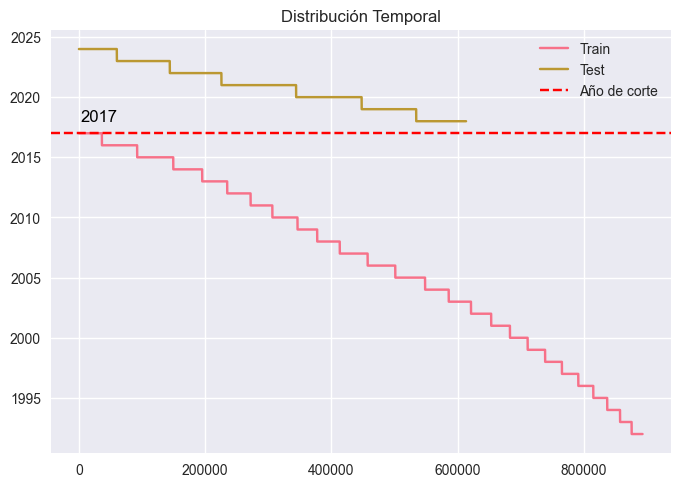

In [37]:
# grafico comparativo de la variable temporal
plt.plot(train['year'], label="Train")
plt.plot(test['year'], label="Test")

## anadir una linea horizonalt en el 2017
plt.axhline(y=2017, color='r', linestyle='--', label='Año de corte')
plt.text(2017, 2018, '2017', color='black', fontsize=12)
plt.legend()
plt.title("Distribución Temporal")
plt.show()

Validamos que nuestro dataset cumpla con las condiciones de tiempo y que no haya fugas de datos entre train y test.


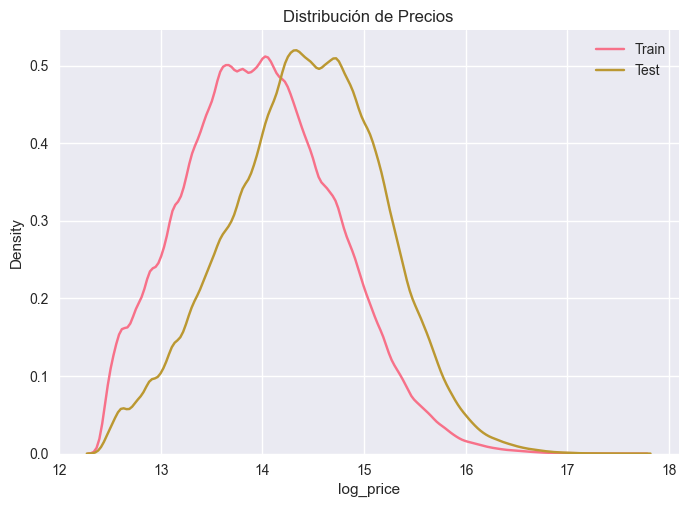

In [38]:
sns.kdeplot(train['log_price'], label='Train')
sns.kdeplot(test['log_price'], label='Test')
plt.title("Distribución de Precios")
plt.legend()
plt.show()


In [39]:
import optuna
import h2o
import pandas as pd
from joblib import load, dump
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from functools import partial
from h2o.estimators import H2OXGBoostEstimator


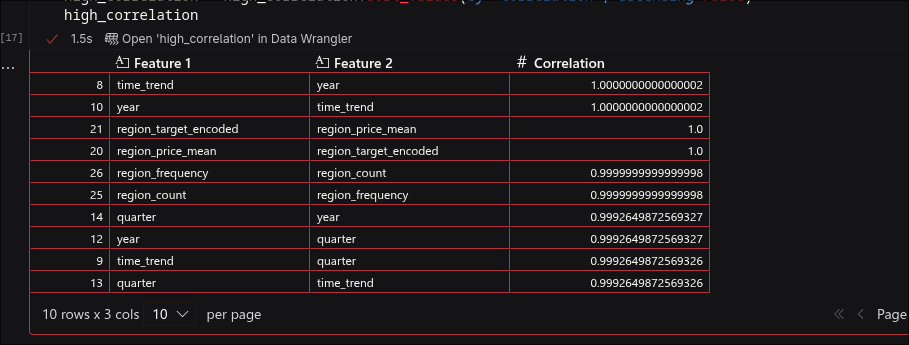

In [40]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 🔧 FUNCIONES
def load_scaled_data(target=TARGET):
    # 1. Cargar features seleccionados
    selected_features = open(SELECTED_FEATURES_FILE).read().splitlines()
    
    exclude_features = [TARGET, "quarter", "region_count", "price_deviation_from_median", "time_trend", "region_target_encoded", "region_count"]
    
    selected_features = [f for f in selected_features if f not in exclude_features]

    # 2. Cargar datasets
    train = pd.read_parquet(TRAIN_DATA_FILE)
    test = pd.read_parquet(TEST_DATA_FILE)

    # 3. Separar X e y
    
    
    X_train_raw = train[selected_features]
    X_test_raw = test[selected_features]
    
    y_train = train[target].reset_index(drop=True)
    y_test = test[target].reset_index(drop=True)

    # 4. Escalar X con StandardScaler
    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=selected_features)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=selected_features)
    
    if TARGET in X_train.columns:
        X_train = X_train.drop(columns=[TARGET])
        X_test = X_test.drop(columns=[TARGET])


    return X_train, X_test, y_train, y_test, selected_features, scaler


In [41]:
# 📦 CARGAR DATA
X_train, X_test, y_train, y_test, features, scaler = load_scaled_data(target=TARGET)


In [42]:
X_train.corr()

,month_sin,month_cos,quarter_sin,quarter_cos,price_per_sqm,price_category_Premium,price_category_Medium,price_per_sqm_x_region,price_category_High,is_premium,...,phase_covid_era,sqm,sales_type_regular_sale,age_x_villa,region_frequency,sales_type_family_sale,sqm_x_region,rooms_sqm_ratio,house_type_Summerhouse,no_rooms
month_sin,1.000000,-0.033077,0.463218,0.785145,-0.012257,-0.010196,0.002430,-0.011551,-0.004186,-0.000751,...,NaN,0.010132,-0.009321,-0.006319,0.006078,0.010869,0.000686,-0.006615,-0.015235,0.009201
month_cos,-0.033077,1.000000,-0.803999,0.426000,0.013488,0.009392,-0.006394,-0.007478,-0.005640,0.014560,...,NaN,0.000685,-0.057626,-0.003735,0.003448,0.053004,0.003584,-0.012841,-0.022537,-0.007334
quarter_sin,0.463218,-0.803999,1.000000,0.001282,-0.015663,-0.011656,0.005552,-0.000351,0.002138,-0.010583,...,NaN,0.003531,0.042880,0.000208,0.000034,-0.039085,-0.002510,0.006457,0.009315,0.009947
quarter_cos,0.785145,0.426000,0.001282,1.000000,-0.006231,-0.005108,-0.001076,-0.012953,-0.006248,0.004102,...,NaN,0.010496,-0.028043,-0.006007,0.006601,0.025861,0.002087,-0.014392,-0.028452,0.005595
price_per_sqm,-0.012257,0.013488,-0.015663,-0.006231,1.000000,0.661324,-0.177241,0.059842,0.125214,0.560183,...,NaN,-0.255816,0.041815,-0.072775,-0.030312,-0.059706,0.088004,0.044353,-0.030731,-0.260159
price_category_Premium,-0.010196,0.009392,-0.011656,-0.005108,0.661324,1.000000,-0.280384,0.129320,-0.241885,0.561847,...,NaN,0.144736,0.040312,-0.046785,-0.018456,-0.042217,0.101827,-0.111179,-0.114367,0.091242
price_category_Medium,0.002430,-0.006394,0.005552,-0.001076,-0.177241,-0.280384,1.000000,-0.059767,-0.333634,-0.157849,...,NaN,-0.021475,0.026118,-0.001929,0.000475,-0.012891,-0.045114,0.010507,0.008637,-0.008176
price_per_sqm_x_region,-0.011551,-0.007478,-0.000351,-0.012953,0.059842,0.129320,-0.059767,1.000000,-0.039469,-0.094802,...,NaN,0.049134,0.040182,0.012057,-0.030771,-0.022379,-0.190922,-0.021795,-0.055507,0.049788
price_category_High,-0.004186,-0.005640,0.002138,-0.006248,0.125214,-0.241885,-0.333634,-0.039469,1.000000,-0.135161,...,NaN,0.042667,0.066441,-0.056780,-0.000043,-0.057729,-0.014602,-0.049735,-0.067610,0.034251
is_premium,-0.000751,0.014560,-0.010583,0.004102,0.560183,0.561847,-0.157849,-0.094802,-0.135161,1.000000,...,NaN,0.148122,-0.011932,-0.014277,-0.003469,0.001789,0.042793,-0.090453,-0.068046,0.091145


<Axes: >

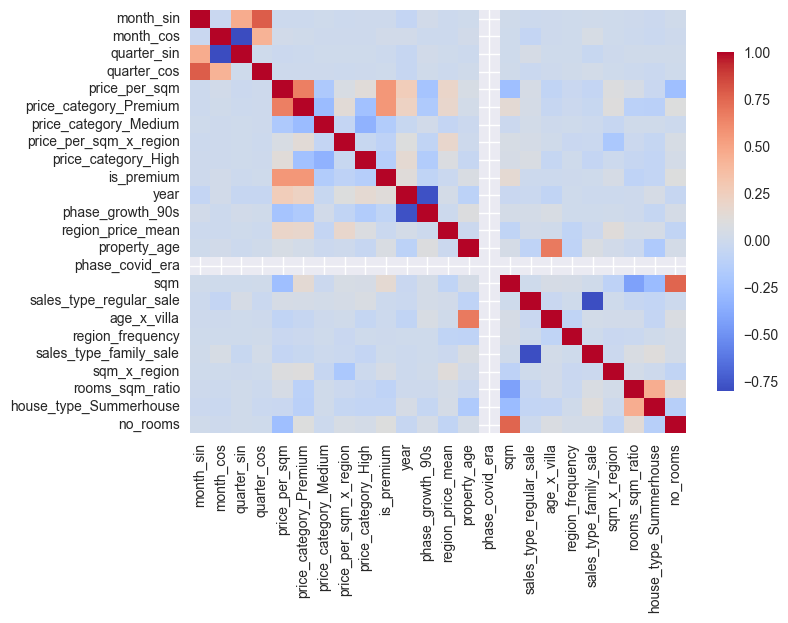

In [43]:

sns.heatmap(X_train.corr(), annot=False, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8})


In [44]:
#obtener las mas altas correlaciones
correlation_matrix = X_train.corr()
high_correlation = correlation_matrix[abs(correlation_matrix) > 0.8].stack().reset_index()
high_correlation.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_correlation = high_correlation[high_correlation['Feature 1'] != high_correlation['Feature 2']]
high_correlation = high_correlation.sort_values(by='Correlation', ascending=False)

if high_correlation.empty:
    print("No hay correlaciones altas (>0.8) entre las variables.")
else:
    print("Correlaciones altas (>0.8) entre las variables:")
    print(high_correlation)

Correlaciones altas (>0.8) entre las variables:
     Feature 1    Feature 2  Correlation
2    month_cos  quarter_sin    -0.803999
3  quarter_sin    month_cos    -0.803999


In [45]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

train_h2o = h2o.H2OFrame(df_train)
test_h2o = h2o.H2OFrame(df_test)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [46]:

train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
test_h2o[TARGET] = test_h2o[TARGET].asnumeric()

In [48]:
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial, features, target, train_h2o, test_h2o):
    params = {
        "ntrees": trial.suggest_int("ntrees", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "learn_rate": trial.suggest_float("learn_rate", 0.01, 0.2),
        "col_sample_rate": trial.suggest_float("col_sample_rate", 0.6, 1.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "min_rows": trial.suggest_int("min_rows", 1, 10),
        "backend": "gpu",  
        "seed": 42
    }

    model = H2OXGBoostEstimator(**params)
    model.train(x=features, y=target, training_frame=train_h2o)

    preds = model.predict(test_h2o).as_data_frame().values.ravel()
    true = test_h2o[target].as_data_frame().values.ravel()
    


    rmse = np.sqrt(mean_squared_error(true, preds))
    return rmse

    

# ⛓️ WRAP con partial
objective_fn = partial(
    objective,
    features=features,
    target=TARGET,
    train_h2o=train_h2o,
    test_h2o=test_h2o
)

In [49]:

study_name = "h2o_xgb_gpu_tuning2"
storage_url = f"sqlite:///{study_name}.db"

study = optuna.create_study(
    direction="minimize",
    study_name=study_name,
    storage=storage_url,
    load_if_exists=True
)

study.optimize(objective_fn, n_trials=10)

print("✅ Best trial:")
print(study.best_trial.params)

[I 2025-12-03 21:08:24,964] Using an existing study with name 'h2o_xgb_gpu_tuning2' instead of creating a new one.
[W 2025-12-03 21:08:29,240] Trial 11 failed with parameters: {'ntrees': 120, 'max_depth': 12, 'learn_rate': 0.19401797824416617, 'col_sample_rate': 0.8665299158308332, 'subsample': 0.8535039816922237, 'min_rows': 6} because of the following error: H2OResponseError(<h2o.schemas.error.H2OErrorV3 object at 0x00000291FDF939D0>).
Traceback (most recent call last):
  File "c:\Users\rosar\RufoEsEterno\DataMining\dataMiningvenv\lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\rosar\AppData\Local\Temp\ipykernel_19656\891640818.py", line 17, in objective
    model.train(x=features, y=target, training_frame=train_h2o)
  File "c:\Users\rosar\RufoEsEterno\DataMining\dataMiningvenv\lib\site-packages\h2o\estimators\estimator_base.py", line 107, in train
    self._train(parms, verbose=verbose)
  File "c:\Users\rosar\R

H2OResponseError: Server error water.exceptions.H2ONotFoundArgumentException:
  Error: POST /3/ModelBuilders/xgboost not found
  Request: POST /3/ModelBuilders/xgboost
    data: {'training_frame': 'py_13_sid_9b65', 'nfolds': '0', 'keep_cross_validation_models': 'True', 'keep_cross_validation_predictions': 'False', 'keep_cross_validation_fold_assignment': 'False', 'score_each_iteration': 'False', 'fold_assignment': 'auto', 'response_column': 'log_price', 'ignore_const_cols': 'True', 'stopping_rounds': '0', 'stopping_metric': 'auto', 'stopping_tolerance': '0.001', 'max_runtime_secs': '0.0', 'seed': '42', 'distribution': 'auto', 'tweedie_power': '1.5', 'categorical_encoding': 'auto', 'quiet_mode': 'True', 'ntrees': '120', 'max_depth': '12', 'min_rows': '6', 'min_child_weight': '1.0', 'learn_rate': '0.19401797824416617', 'eta': '0.3', 'sample_rate': '1.0', 'subsample': '0.8535039816922237', 'col_sample_rate': '0.8665299158308332', 'colsample_bylevel': '1.0', 'col_sample_rate_per_tree': '1.

In [ ]:
study.best_trial.params

{'ntrees': 124,
 'max_depth': 11,
 'learn_rate': 0.19670002317226132,
 'col_sample_rate': 0.8444486648267129,
 'sample_rate': 0.60359471153855,
 'min_rows': 3}

In [ ]:
best_params = study.best_trial.params
best_model = H2OXGBoostEstimator(**best_params)
best_model.train(x=features, y=TARGET, training_frame=train_h2o)
best_model_path = best_model.save_mojo(path="models/", force=True)
print(f"📦 Modelo guardado en: {best_model_path}")


H2OResponseError: Server error water.exceptions.H2ONotFoundArgumentException:
  Error: POST /3/ModelBuilders/xgboost not found
  Request: POST /3/ModelBuilders/xgboost
    data: {'training_frame': 'py_1_sid_80cd', 'nfolds': '0', 'keep_cross_validation_models': 'True', 'keep_cross_validation_predictions': 'False', 'keep_cross_validation_fold_assignment': 'False', 'score_each_iteration': 'False', 'fold_assignment': 'auto', 'response_column': 'log_price', 'ignore_const_cols': 'True', 'stopping_rounds': '0', 'stopping_metric': 'auto', 'stopping_tolerance': '0.001', 'max_runtime_secs': '0.0', 'seed': '-1', 'distribution': 'auto', 'tweedie_power': '1.5', 'categorical_encoding': 'auto', 'quiet_mode': 'True', 'ntrees': '124', 'max_depth': '11', 'min_rows': '3', 'min_child_weight': '1.0', 'learn_rate': '0.19670002317226132', 'eta': '0.3', 'sample_rate': '0.60359471153855', 'subsample': '1.0', 'col_sample_rate': '0.8444486648267129', 'colsample_bylevel': '1.0', 'col_sample_rate_per_tree': '1.0',

In [ ]:
from optuna.visualization.matplotlib import plot_param_importances, plot_optimization_history
import matplotlib.pyplot as plt

plot_param_importances(study)
plt.show()

plot_optimization_history(study)
plt.show()


In [ ]:
evaluation = best_model.model_performance(test_data=test_h2o)
print("RMSE en test:", evaluation.rmse())

In [ ]:
from h2o.automl import H2OAutoML

aml = H2OAutoML(
    max_runtime_secs=600,           # ⏱️ tiempo total (ajustá según tu disponibilidad)
    seed=42,
    include_algos=["XGBoost"],      # ⚡ Solo modelos con soporte GPU
    sort_metric="RMSE",            # O 'MAE', 'R2', etc.
    keep_cross_validation_predictions=True
)

aml.train(x=features, y=TARGET, training_frame=train_h2o)


In [ ]:
# Evaluar en test_h2o
perf_automl = aml.leader.model_performance(test_h2o)
print("🔍 AutoML RMSE:", perf_automl.rmse())

# Comparar con Optuna-tuneado
perf_optuna = best_model.model_performance(test_h2o)
print("🎯 Optuna RMSE:", perf_optuna.rmse())



In [ ]:
# ==================================================
# 📊 EVALUACIÓN COMPRENSIVA DE MODELOS
# ==================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def calculate_mape(y_true, y_pred):
    """Calcula MAPE evitando división por cero"""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(model, test_h2o, model_name):
    """Evalúa un modelo H2O y retorna métricas"""
    # Predicciones
    preds = model.predict(test_h2o).as_data_frame().values.ravel()
    true = test_h2o[TARGET].as_data_frame().values.ravel()
    
    # Métricas
    rmse = np.sqrt(mean_squared_error(true, preds))
    mae = mean_absolute_error(true, preds)
    r2 = r2_score(true, preds)
    mape = calculate_mape(true, preds)
    
    return {
        'Modelo': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE (%)': mape,
        'Predicciones': preds,
        'Reales': true
    }

# Evaluar ambos modelos
results = []
results.append(evaluate_model(best_model, test_h2o, "XGBoost Optuna"))
results.append(evaluate_model(aml.leader, test_h2o, "AutoML Leader"))

print("✅ Evaluación completada")

In [ ]:
# ==================================================
# 📈 TABLA COMPARATIVA Y VISUALIZACIONES
# ==================================================

# Crear tabla comparativa
comparison_df = pd.DataFrame(results)[['Modelo', 'RMSE', 'MAE', 'R²', 'MAPE (%)']]
comparison_df = comparison_df.round(4)

print("🏆 COMPARACIÓN DE MODELOS:")
print("=" * 50)
print(comparison_df.to_string(index=False))

# Identificar mejor modelo
best_idx = comparison_df['RMSE'].idxmin()
best_model_name = comparison_df.iloc[best_idx]['Modelo']
print(f"\n🥇 Mejor modelo: {best_model_name}")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predicciones vs Reales
for i, result in enumerate(results):
    axes[0, 0].scatter(result['Reales'], result['Predicciones'], 
                      alpha=0.6, label=result['Modelo'], s=1)
axes[0, 0].plot([min(results[0]['Reales']), max(results[0]['Reales'])], 
                [min(results[0]['Reales']), max(results[0]['Reales'])], 'r--', alpha=0.8)
axes[0, 0].set_xlabel('Valores Reales')
axes[0, 0].set_ylabel('Predicciones')
axes[0, 0].set_title('Predicciones vs Valores Reales')
axes[0, 0].legend()

# 2. Distribución de Residuos
for i, result in enumerate(results):
    residuals = result['Reales'] - result['Predicciones']
    axes[0, 1].hist(residuals, bins=50, alpha=0.7, label=result['Modelo'], density=True)
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].set_title('Distribución de Residuos')
axes[0, 1].legend()

# 3. Métricas comparativas
metrics = ['RMSE', 'MAE', 'R²', 'MAPE (%)']
x_pos = np.arange(len(metrics))
width = 0.35

for i, result in enumerate(results):
    values = [comparison_df.iloc[i]['RMSE'], comparison_df.iloc[i]['MAE'], 
              comparison_df.iloc[i]['R²'], comparison_df.iloc[i]['MAPE (%)']]
    axes[1, 0].bar(x_pos + i*width, values, width, label=result['Modelo'])

axes[1, 0].set_xlabel('Métricas')
axes[1, 0].set_ylabel('Valores')
axes[1, 0].set_title('Comparación de Métricas')
axes[1, 0].set_xticks(x_pos + width/2)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].legend()

# 4. Residuos vs Predicciones
for i, result in enumerate(results):
    residuals = result['Reales'] - result['Predicciones']
    axes[1, 1].scatter(result['Predicciones'], residuals, 
                      alpha=0.6, label=result['Modelo'], s=1)
axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
axes[1, 1].set_xlabel('Predicciones')
axes[1, 1].set_ylabel('Residuos')
axes[1, 1].set_title('Residuos vs Predicciones')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ==================================================
# 🎯 ANÁLISIS DE IMPORTANCIA Y RESUMEN FINAL
# ==================================================

# Feature Importance del mejor modelo
print("🔍 IMPORTANCIA DE VARIABLES:")
print("=" * 40)

# Obtener importancia de variables
varimp = best_model.varimp(use_pandas=True)
top_features = varimp.head(10)

print(top_features.to_string(index=False))

# Visualizar importancia
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_features['scaled_importance'])
plt.yticks(range(len(top_features)), top_features['variable'])
plt.xlabel('Importancia Relativa')
plt.title('Top 10 Variables Más Importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Guardar resultados
results_summary = {
    'best_model': best_model_name,
    'metrics': comparison_df.to_dict('records'),
    'feature_importance': top_features.to_dict('records'),
    'total_test_samples': len(results[0]['Reales'])
}

# Guardar en archivo
import json
with open('results/model_evaluation_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"\n💾 Resultados guardados en: results/model_evaluation_summary.json")
print(f"📊 Muestras evaluadas: {results_summary['total_test_samples']:,}")
print("✅ Evaluación completa finalizada")